In [1]:
# Import a few libraries that may be useful for this project
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import glob
import os
from pathlib import  Path
import fnmatch
#import cmocean as cmo
# set seed at the beginning for reproducibility
seed=42
np.random.seed(seed)

In [ ]:
# load the tea data
tea_df=pd.read_excel('processed/OSL_Demonstration_Data_Collection_in_Tea_Plantation.xlsx', sheet_name='data')
# add the yield per heactare column
tea_df['yield_kg_ha'] = tea_df['yield_kg'] / tea_df['area_ha']
tea_df.head()

,Timestamp,date,Farm,treatment,area_ha,yield_kg,data_entry,replicate,yield_kg_ha
0,2025-12-16 15:45:24.564,2025-12-15,Bigutu,OSL27-250,3.0000,496.00,Emmanuel,NaN,165.333333
1,2025-12-16 15:49:34.600,2025-12-15,Bigutu,control,1.5000,198.00,Emmanuel,NaN,132.000000
2,2025-12-20 10:05:45.270,2025-12-18,RAB,NPK50-OSL31-250,0.0025,1.02,Francois,1.0,408.000000
3,2025-12-20 10:07:09.166,2025-12-18,RAB,NPK70-OSL31-250,0.0025,0.87,Francois,1.0,348.000000
4,2025-12-20 10:08:11.319,2025-12-18,RAB,NPK80-OSL31-250,0.0025,0.80,Francois,1.0,320.000000


In [3]:
# check data info
tea_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    311 non-null    datetime64[ns]
 1   date         311 non-null    datetime64[ns]
 2   Farm         311 non-null    object        
 3   treatment    311 non-null    object        
 4   area_ha      311 non-null    float64       
 5   yield_kg     311 non-null    float64       
 6   data_entry   311 non-null    object        
 7   replicate    261 non-null    float64       
 8   yield_kg_ha  311 non-null    float64       
dtypes: datetime64[ns](2), float64(4), object(3)
memory usage: 22.0+ KB


It looks like the date colum is the date time.
Now we will calculate the day of the year from the date column

In [4]:
# get the day of the year from date colum
tea_df['day']=pd.to_datetime(tea_df.date).dt.dayofyear
tea_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    311 non-null    datetime64[ns]
 1   date         311 non-null    datetime64[ns]
 2   Farm         311 non-null    object        
 3   treatment    311 non-null    object        
 4   area_ha      311 non-null    float64       
 5   yield_kg     311 non-null    float64       
 6   data_entry   311 non-null    object        
 7   replicate    261 non-null    float64       
 8   yield_kg_ha  311 non-null    float64       
 9   day          311 non-null    int32         
dtypes: datetime64[ns](2), float64(4), int32(1), object(3)
memory usage: 23.2+ KB


In [ ]:
# get the fertilizer reduction experiment data
rab_data=tea_df.query('Farm=="RAB"')
rab_data.head()

,Timestamp,date,Farm,treatment,area_ha,yield_kg,data_entry,replicate,yield_kg_ha,day
2,2025-12-20 10:05:45.270,2025-12-18,RAB,NPK50-OSL31-250,0.0025,1.02,Francois,1.0,408.0,352
3,2025-12-20 10:07:09.166,2025-12-18,RAB,NPK70-OSL31-250,0.0025,0.87,Francois,1.0,348.0,352
4,2025-12-20 10:08:11.319,2025-12-18,RAB,NPK80-OSL31-250,0.0025,0.80,Francois,1.0,320.0,352
5,2025-12-20 10:13:14.221,2025-12-18,RAB,NPK100-OSL31-250,0.0025,0.93,Francois,1.0,372.0,352
6,2025-12-20 10:14:49.483,2025-12-18,RAB,control,0.0025,1.03,Francois,1.0,412.0,352


In [11]:
# get the data from industrial blocks
# This is tier_2 data for macroscale model

gtc_data=tea_df.query('Farm!="RAB"')

# add plotID for the two plots

gtc_data.loc[:,'plotid']=gtc_data['treatment'].map({'OSL27-250':'Plot_1', 'control':'Plot_2'})

gtc_data.head()

C:\Users\Benjamin\AppData\Local\Temp\ipykernel_15756\3673913519.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtc_data.loc[:,'plotid']=gtc_data['treatment'].map({'OSL27-250':'Plot_1', 'control':'Plot_2'})


,Timestamp,date,Farm,treatment,area_ha,yield_kg,data_entry,replicate,yield_kg_ha,day,plotid
0,2025-12-16 15:45:24.564,2025-12-15,Bigutu,OSL27-250,3.0,496.0,Emmanuel,NaN,165.333333,349,Plot_1
1,2025-12-16 15:49:34.600,2025-12-15,Bigutu,control,1.5,198.0,Emmanuel,NaN,132.000000,349,Plot_2
22,2025-12-24 15:46:13.859,2025-12-23,Ntendezi,OSL27-250,0.2,138.0,Emmanuel,NaN,690.000000,357,Plot_1
23,2025-12-24 15:46:59.752,2025-12-23,Ntendezi,control,0.2,64.9,Emmanuel,NaN,324.500000,357,Plot_2
44,2026-01-05 07:25:11.426,2025-12-30,Bigutu,OSL27-250,3.0,361.0,Emmanuel,NaN,120.333333,364,Plot_1


In [ ]:
# Model for Tier 2 (Macro-Scale)
#Fit the Linear Mixed-Effects Model for Tier 2
# We will check all 2-way and 3-way interactions 
tier2_model = smf.mixedlm(
    "yield_kg_ha ~ C(treatment) * C(Farm) * day", 
    data=gtc_data, 
    groups=gtc_data["plotid"]
)
tier2_results = tier2_model.fit()

print("\n====================================================")
print("            TIER 2 MODEL RESULTS SUMMARY            ")
print("====================================================")
print(tier2_results.summary())


            TIER 2 MODEL RESULTS SUMMARY            
                             Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             yield_kg_ha
No. Observations:               50                  Method:                         REML       
No. Groups:                     2                   Scale:                          2549.3520  
Min. group size:                25                  Log-Likelihood:                 -252.6537  
Max. group size:                25                  Converged:                      Yes        
Mean group size:                25.0                                                           
-----------------------------------------------------------------------------------------------
                                                 Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------------------------------------
Intercept      

c:\Users\Benjamin\anaconda3\envs\stats\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


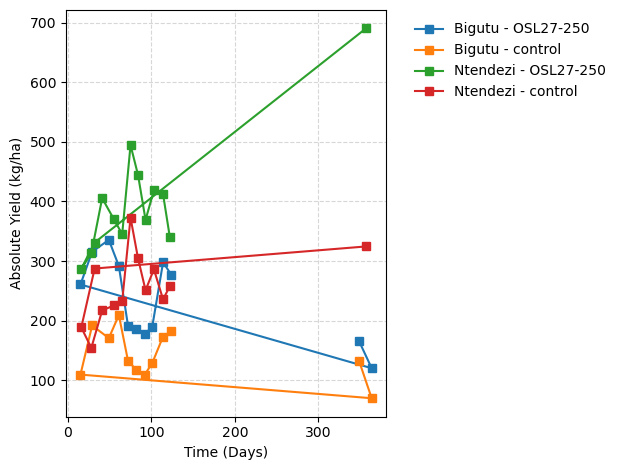

In [24]:
plt.Figure(figsize=[7,5])
# Plot Tier 2: Hectare Scale Multi-Site Validation
for (site, trt), group in gtc_data.groupby(['Farm', 'treatment']):
    label_str = f"{site} - {trt}"
    plt.plot(group['day'], group['yield_kg_ha'], marker='s', linestyle=None, label=label_str)
plt.xlabel('Time (Days)')
plt.ylabel('Absolute Yield (kg/ha)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()